# Advanced Measurements with PyTestLab

Build a complete, reproducible measurement workflow—from a simulated instrument to a validated, plotted, and exported experiment.

> **What you will build**  
> A small voltage-response characterization that runs without laboratory hardware and uses the same session structure you can carry into a real bench.

## Learning objectives

By the end of this tutorial you will be able to:

- create and safely close a simulated instrument;
- define a multi-parameter sweep with `MeasurementSession`;
- register an acquisition function that returns structured results;
- inspect and validate results with Polars;
- plot a response and export a portable Parquet artifact.

## Prerequisites

- Python 3.11 or newer;
- PyTestLab installed: `python -m pip install pytestlab`; and
- basic Python and NumPy familiarity.

No instruments are required. Every acquisition in the default path uses `simulate=True`.

## 1. The measurement workflow

A robust PyTestLab experiment has four layers:

1. **Configure** instruments and safety limits.
2. **Acquire** data through a named session and an explicit measurement function.
3. **Inspect** the tabular result before trusting or sharing it.
4. **Preserve** the data and the choices that produced it.

`MeasurementSession` owns the sweep and lifecycle. Its acquisition function receives sweep parameters and instruments by name, then returns a dictionary that becomes one row of the experiment.

In [1]:
import logging
import tempfile
import warnings
from contextlib import redirect_stderr
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path

logging.getLogger("pytestlab.sim.v2").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import polars as pl  # noqa: E402

import pytestlab  # noqa: E402
from pytestlab import AutoInstrument  # noqa: E402
from pytestlab import MeasurementSession  # noqa: E402
from pytestlab.plotting import PlotSpec  # noqa: E402
from pytestlab.plotting import plot_dataframe  # noqa: E402

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print(f"PyTestLab {pytestlab.__version__}")
print(f"NumPy {np.__version__} · Polars {pl.__version__}")

PyTestLab 0.3.0
NumPy 2.3.2 · Polars 1.32.3


## 2. Start with a safe instrument lifecycle

Simulation uses the same high-level instrument API as hardware, but it routes commands to a local profile-backed simulator. That makes the notebook deterministic to start and safe to run in CI.

The `try/finally` pattern is still important: outputs must be disabled and resources closed even when an acquisition fails.

In [2]:
# Redirect profile diagnostics so the lesson stays focused on the API.
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    psu = AutoInstrument.from_config("keysight/EDU36311A", simulate=True)

try:
    print(psu.id())
    psu.channel(1).set(voltage=3.3, current_limit=0.1).on()
    print("Channel 1 configured: 3.3 V, 100 mA limit")
finally:
    psu.channel(1).off()
    psu.close()
    print("Output disabled and instrument closed")

2026-07-23 02:46:56,329 pytestlab.sim.v2 INFO – SimBackend initialised for EDU36311A


Simulated,PyTestLab,EDU36311A-SIM,1.0
Channel 1 configured: 3.3 V, 100 mA limit
Output disabled and instrument closed


## 3. Define a multi-parameter acquisition

We will characterize a simulated DUT at five source voltages and three load values. The session creates the Cartesian product: 15 measurement points in total.

The DUT response below is intentionally simple and deterministic. In a hardware experiment, replace the model with readings from a DMM, oscilloscope, or other instrument; keep the session and result schema unchanged.

In [3]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    with MeasurementSession(
        name="DUT voltage response",
        description="Simulation-first voltage/load characterization",
        compliance=False,
    ) as session:
        session.parameter(
            "source_voltage",
            np.linspace(0.5, 5.0, 5),
            unit="V",
            notes="Programmed supply voltage",
        )
        session.parameter("load_ohms", [100, 220, 470], unit="Ω")
        session.instrument("psu", "keysight/EDU36311A", simulate=True)

        @session.acquire
        def measure_dut(source_voltage, load_ohms, psu):
            # Configure the stimulus with an explicit current limit.
            psu.set_voltage(1, float(source_voltage))
            psu.set_current(1, 0.1)
            psu.output(1, True)
            try:
                # Replace this model with real instrument reads in hardware mode.
                droop = 0.02 * np.log1p(load_ohms / 100)
                measured_voltage = source_voltage * (1 - droop)
                current = measured_voltage / load_ohms
                return {
                    "measured_voltage": measured_voltage,
                    "current_a": current,
                    "power_w": measured_voltage * current,
                }
            finally:
                psu.output(1, False)

        experiment = session.run(show_progress=False)

print(f"Collected {experiment.data.height} rows")
print(f"Columns: {', '.join(experiment.data.columns)}")

2026-07-23 02:46:56,349 pytestlab.sim.v2 INFO – SimBackend initialised for EDU36311A


Collected 15 rows
Columns: source_voltage, load_ohms, timestamp, measured_voltage, current_a, power_w


## 4. Inspect the result before interpreting it

`experiment.data` is a Polars `DataFrame`. Keep the raw table available, then derive summaries for reports and plots. The parameter columns describe the stimulus; returned dictionary keys describe observations or calculated quantities.

In [4]:
data = experiment.data.sort(["load_ohms", "source_voltage"])
data.head(8)

source_voltage,load_ohms,timestamp,measured_voltage,current_a,power_w
f64,i64,f64,f64,f64,f64
0.5,100,1.7848e9,0.493069,0.004931,0.002431
1.625,100,1.7848e9,1.602473,0.016025,0.025679
2.75,100,1.7848e9,2.711877,0.027119,0.073543
3.875,100,1.7848e9,3.821281,0.038213,0.146022
5.0,100,1.7848e9,4.930685,0.049307,0.243117
0.5,220,1.7848e9,0.488368,0.00222,0.001084
1.625,220,1.7848e9,1.587198,0.007215,0.011451
2.75,220,1.7848e9,2.686027,0.012209,0.032794


In [5]:
summary = (
    data.group_by("load_ohms")
    .agg(
        pl.len().alias("points"),
        pl.col("measured_voltage").min().alias("min_voltage_v"),
        pl.col("measured_voltage").max().alias("max_voltage_v"),
        pl.col("power_w").mean().alias("mean_power_w"),
    )
    .sort("load_ohms")
)
summary

load_ohms,points,min_voltage_v,max_voltage_v,mean_power_w
i64,u32,f64,f64,f64
100,5,0.493069,4.930685,0.098158
220,5,0.488368,4.883685,0.043771
470,5,0.482595,4.825953,0.020007


## 5. Add lightweight quality gates

Assertions are useful in notebooks because they turn assumptions into executable checks. For production work, promote these checks into tests or a compliance policy, but keep the intent visible next to the acquisition.

In [6]:
expected_points = 5 * 3
assert data.height == expected_points
assert data.select(pl.all().is_not_null()).to_numpy().all()
assert (data["measured_voltage"] >= 0).all()
assert (data["power_w"] >= 0).all()

print("Quality gates passed: row count, nulls, voltage, and power")

Quality gates passed: row count, nulls, voltage, and power


## 6. Plot one comparable series

Because the sweep contains three loads, filter to one load before drawing a line. This avoids connecting unrelated series and makes the chart a faithful view of one experiment slice.

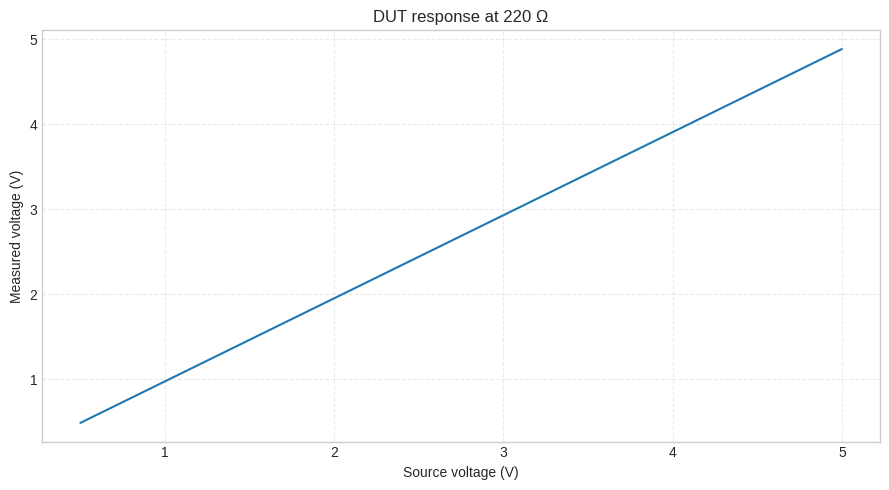

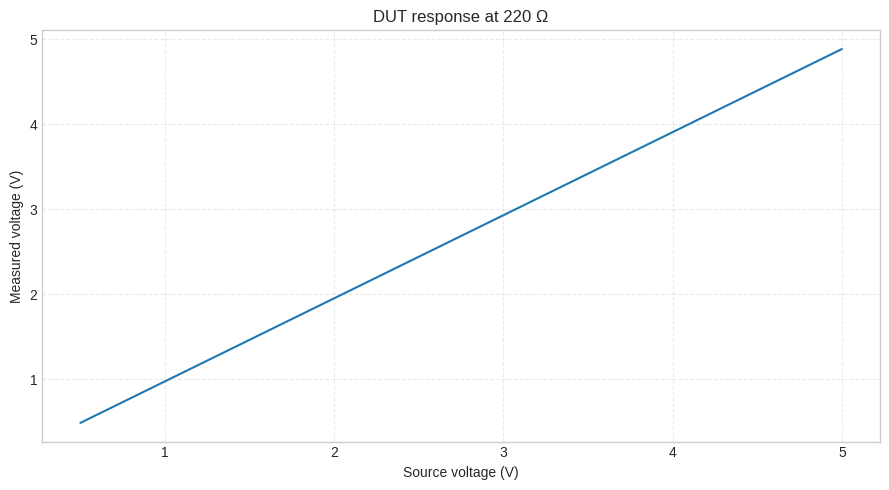

In [7]:
selected_load = 220
series = data.filter(pl.col("load_ohms") == selected_load).sort("source_voltage")

figure = plot_dataframe(
    series,
    PlotSpec(
        kind="line",
        x="source_voltage",
        y="measured_voltage",
        title=f"DUT response at {selected_load} Ω",
        xlabel="Source voltage (V)",
        ylabel="Measured voltage (V)",
        legend=False,
    ),
)
figure

## 7. Export and reload the artifact

Parquet preserves column names and types while remaining compact and easy to reload with Polars. In a real project, pair the file with the session name, profile revision, operator, and any compliance metadata required by your lab.

In [8]:
export_dir = Path(tempfile.mkdtemp(prefix="pytestlab-advanced-"))
export_path = export_dir / "dut_voltage_response.parquet"
experiment.save_parquet(str(export_path))
reloaded = pl.read_parquet(export_path)

assert reloaded.shape == data.shape
print(f"Saved and reloaded {reloaded.height} rows from {export_path.name}")

Data saved to Parquet file at: /tmp/pytestlab-advanced-y30rzvwo/dut_voltage_response.parquet
Saved and reloaded 15 rows from dut_voltage_response.parquet


## 8. Move from simulation to hardware

The simulation flag is the main boundary in this tutorial. For a real lab setup:

1. define the instrument profile and resource address;
2. replace `simulate=True` with the hardware connection settings;
3. replace the DUT model with instrument reads;
4. retain the current limit, `try/finally`, validation, and export steps; and
5. use `Bench.open(...)` when several instruments and shared experiment metadata should be managed together.

Do not remove the output shutdown just because a bench normally handles cleanup. Defense in depth is appropriate around energized hardware.

## Takeaways

You now have a reusable pattern for advanced measurements:

- `MeasurementSession` defines the experiment boundary and sweep;
- acquisition functions return named, analysis-ready values;
- Polars makes inspection and quality checks explicit; and
- the exported Parquet file is a portable handoff to analysis or archival systems.

Next, compare this notebook with the [MeasurementSession user guide](../user_guide/measurement_session.md), then explore [Record & Replay](replay_mode.ipynb) for hardware-backed reproducibility.